In [ ]:
# ============================================================
# Question 1: Baseline Reproduction (consistent variables)
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.tree import DecisionTreeClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from evaluate import evaluate_prediction_csvs
import os
import glob
from typing import List, Dict

# ------------------------------
# 1. Paths and feature keys
# ------------------------------
base_path = Path("D:\\JKU\\Semester 3\\PC\\Task 5")
train_path = base_path / "train"
val_path = base_path / "validation"

FEATURE_KEYS = [
    'zcr_mean', 'zcr_std', 'zcr_min', 'zcr_max',
    'melspect_mean', 'melspect_std', 'melspect_min', 'melspect_max',
    'mfcc_mean', 'mfcc_std', 'mfcc_min', 'mfcc_max',
    'mfcc_d_mean', 'mfcc_d_std', 'mfcc_d_min', 'mfcc_d_max',
    'mfcc_d2_mean', 'mfcc_d2_std', 'mfcc_d2_min', 'mfcc_d2_max',
    'flux_mean', 'flux_std', 'flux_min', 'flux_max',
    'flatness_mean', 'flatness_std', 'flatness_min', 'flatness_max',
    'centroid_mean', 'centroid_std', 'centroid_min', 'centroid_max',
    'bandwidth_mean', 'bandwidth_std', 'bandwidth_min', 'bandwidth_max',
    'contrast_mean', 'contrast_std', 'contrast_min', 'contrast_max',
    'rolloff_low_mean', 'rolloff_low_std', 'rolloff_low_min', 'rolloff_low_max',
    'rolloff_high_mean', 'rolloff_high_std', 'rolloff_high_min', 'rolloff_high_max',
    'energy_mean', 'energy_std', 'energy_min', 'energy_max',
    'power_mean', 'power_std', 'power_min', 'power_max',
]

# ------------------------------
# 2. Helper functions (from baseline)
# ------------------------------
def build_feature_matrix(data: dict) -> np.ndarray:
    arrays = []
    for feat_name in FEATURE_KEYS:
        feat = data[feat_name]
        if feat.ndim == 1:
            feat = feat[:, np.newaxis]
        arrays.append(feat.astype(np.float32))
    return np.concatenate(arrays, axis=1)

def get_segment_labels(data: dict) -> np.ndarray:
    annotations = data["annotations"]           # (N, C, A)
    binary = (annotations > 0).astype(int)      # baseline uses >0
    votes = binary.sum(axis=2)                  # (N, C)
    n_annotators = binary.shape[2]
    y = (votes > (n_annotators // 2)).astype(int)
    return y

def load_all_segments(file_list: List[str]) -> tuple:
    X_list, Y_list = [], []
    for filepath in file_list:
        data = dict(np.load(filepath, allow_pickle=True))
        X_list.append(build_feature_matrix(data))
        Y_list.append(get_segment_labels(data))
    return np.vstack(X_list), np.vstack(Y_list)

def predictions_to_intervals(predictions: np.ndarray, start_times: np.ndarray, filename: str, class_names: List[str]) -> List[Dict]:
    rows = []
    for cls_idx, cls_name in enumerate(class_names):
        cls_preds = predictions[:, cls_idx]
        in_event = False
        onset = None
        for t, pred in zip(start_times, cls_preds):
            if pred == 1 and not in_event:
                onset = float(t)
                in_event = True
            elif pred == 0 and in_event:
                offset = float(t)
                rows.append({"filename": filename, "annotation": cls_name,
                             "onset": onset, "offset": offset})
                in_event = False
        if in_event:
            offset = float(start_times[-1]) + 1.0
            rows.append({"filename": filename, "annotation": cls_name,
                         "onset": onset, "offset": offset})
    return rows

# ------------------------------
# 3. Load files and split at file level
# ------------------------------
train_files = sorted(glob.glob(str(train_path / "audio_features" / "*.npz")))
val_files   = sorted(glob.glob(str(val_path   / "audio_features" / "*.npz")))

print(f"Train files: {len(train_files)}, Validation files: {len(val_files)}")

rng = np.random.default_rng(seed=42)
val_files_shuffled = rng.permutation(val_files).tolist()
n_val = len(val_files_shuffled) // 2
our_val_files  = val_files_shuffled[:n_val]   # local validation (not used here)
our_test_files = val_files_shuffled[n_val:]   # non-hidden test set

print(f"Local validation files: {len(our_val_files)}")
print(f"Non-hidden test files:  {len(our_test_files)}")

# Get class names from first training file
sample_data = dict(np.load(train_files[0], allow_pickle=True))
class_names = sample_data['class_names'].tolist()
print(f"Class names: {class_names}")

# ------------------------------
# 4. Load training and test segments
# ------------------------------
print("Loading training segments...")
X_train, y_train = load_all_segments(train_files)          # use lowercase y_train
print(f"Loaded {X_train.shape[0]} training segments with {X_train.shape[1]} features.")

# Optional subsample for speed (same as baseline)
MAX_TRAINING_SEGMENTS = 50_000
if MAX_TRAINING_SEGMENTS is not None and X_train.shape[0] > MAX_TRAINING_SEGMENTS:
    idx = rng.choice(X_train.shape[0], size=MAX_TRAINING_SEGMENTS, replace=False)
    X_train = X_train[idx]
    y_train = y_train[idx]
    print(f"Subsampled to {X_train.shape[0]} segments.")

print("Loading test segments (non-hidden)...")
X_test, y_test = load_all_segments(our_test_files)
print(f"Loaded {X_test.shape[0]} test segments.")

# ------------------------------
# 5. Preprocessing: StandardScaler + PCA
# ------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"PCA components: {X_train_pca.shape[1]}")

# ------------------------------
# 6. Train baseline Decision Trees
# ------------------------------
print("Training Decision Trees (baseline)...")
base_clf = DecisionTreeClassifier(max_depth=10, max_features='sqrt', random_state=42)
clf = MultiOutputClassifier(base_clf, n_jobs=-1)
clf.fit(X_train_pca, y_train)
print("Training complete.")

# ------------------------------
# 7. Generate interval predictions for the non-hidden test set
#    (for official evaluate.py)
# ------------------------------
print("Generating predictions for non‑hidden test set...")
all_rows = []
for filepath in our_test_files:
    data = dict(np.load(filepath, allow_pickle=True))
    X = build_feature_matrix(data)
    X_scaled = scaler.transform(X)
    X_pca = pca.transform(X_scaled)
    preds_all = clf.predict(X_pca)
    start_times = data['start_time']
    whole_mask = np.isclose(start_times % 1.0, 0.0)
    times_whole = start_times[whole_mask]
    preds_whole = preds_all[whole_mask]
    filename = os.path.basename(filepath).replace('.npz', '.wav')
    rows = predictions_to_intervals(preds_whole, times_whole, filename, class_names)
    all_rows.extend(rows)

pred_df = pd.DataFrame(all_rows)
pred_csv = "baseline_predictions_non_hidden_test.csv"
pred_df.to_csv(pred_csv, index=False)
print(f"Saved predictions to {pred_csv} with {len(pred_df)} event intervals.")

# ------------------------------
# 8. Evaluate using official evaluate.py
# ------------------------------
print("\n--- Official Evaluation using evaluate.py ---")
gt_path = str(val_path / "annotations.csv")   # full validation annotations
macro_f1, results_df = evaluate_prediction_csvs(gt_path, pred_csv)
print(f"\nSegment‑based Macro F1: {macro_f1:.4f}")
print("\nPer‑class results:")
print(results_df.to_string(index=False))

Train files: 3704, Validation files: 999
Local validation files: 499
Non-hidden test files:  500
Class names: ['bell_ringing', 'coffee_machine', 'cutlery_dishes', 'door_open_close', 'footsteps', 'keyboard_typing', 'keychain', 'light_switch', 'microwave', 'phone_ringing', 'running_water', 'toilet_flushing', 'vacuum_cleaner', 'wardrobe_drawer_open_close', 'window_open_close']
Loading training segments...
Loaded 170508 training segments with 960 features.
Subsampled to 50000 segments.
Loading test segments (non-hidden)...
Loaded 23646 test segments.
PCA components: 237
Training Decision Trees (baseline)...
Training complete.
Generating predictions for non‑hidden test set...
Saved predictions to baseline_predictions_non_hidden_test.csv with 3162 event intervals.

--- Official Evaluation using evaluate.py ---
Loading ground truth... 
Aggregating ground truth annotations in CSV via majority vote...
Loading predictions... 

Segment‑based Macro F1: 0.1108

Per‑class results:
                an

In [8]:
# ============================================================
# Question 2a: Train Best Classifier (Random Forest)
# ============================================================
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier

# ------------------------------
# Use the same data splits from baseline (already loaded)
# X_train_pca, y_train, X_test_pca, y_test are already defined
# ------------------------------

# ------------------------------
# Train Random Forest (one per class) using MultiOutputClassifier
# ------------------------------
print("\n" + "="*60)
print("Training Random Forest (class_weight='balanced')")
print("="*60)

# Hyperparameters (from Task 4 best model)
rf_params = {
    'n_estimators': 200,
    'max_depth': 10,
    'min_samples_leaf': 5,
    'class_weight': 'balanced',
    'random_state': 42,
    'n_jobs': -1
}

print("Hyperparameters:")
for k, v in rf_params.items():
    print(f"  {k}: {v}")

rf_model = MultiOutputClassifier(
    RandomForestClassifier(**rf_params)
)

rf_model.fit(X_train_pca, y_train)

# ------------------------------
# Evaluate on non‑hidden test set
# ------------------------------
y_pred_test = rf_model.predict(X_test_pca)

per_class_f1_rf = []
for c in range(len(class_names)):
    f1 = f1_score(y_test[:, c], y_pred_test[:, c], zero_division=0)
    per_class_f1_rf.append(f1)

macro_f1_rf = np.mean(per_class_f1_rf)

print("\n" + "="*50)
print("Random Forest Results on Non‑hidden Test Set")
print("="*50)
for i, name in enumerate(class_names):
    print(f"{name:30s} F1 = {per_class_f1_rf[i]:.4f}")
print(f"\nSegment‑based Macro F1 Score: {macro_f1_rf:.4f}")

# ------------------------------
# Compare with baseline (optional, for 2c)
# ------------------------------
print("\n" + "="*50)
print("Comparison: Baseline (Decision Trees) vs Random Forest")
print("="*50)
print(f"Baseline Macro F1: 0.3038")
print(f"Random Forest Macro F1: {macro_f1_rf:.4f}")
print(f"Improvement: {macro_f1_rf - 0.3038:.4f}")



Training Random Forest (class_weight='balanced')
Hyperparameters:
  n_estimators: 200
  max_depth: 10
  min_samples_leaf: 5
  class_weight: balanced
  random_state: 42
  n_jobs: -1

Random Forest Results on Non‑hidden Test Set
bell_ringing                   F1 = 0.2152
coffee_machine                 F1 = 0.4666
cutlery_dishes                 F1 = 0.4689
door_open_close                F1 = 0.3638
footsteps                      F1 = 0.5085
keyboard_typing                F1 = 0.5345
keychain                       F1 = 0.4112
light_switch                   F1 = 0.5318
microwave                      F1 = 0.5720
phone_ringing                  F1 = 0.6078
running_water                  F1 = 0.6661
toilet_flushing                F1 = 0.3935
vacuum_cleaner                 F1 = 0.5702
wardrobe_drawer_open_close     F1 = 0.2884
window_open_close              F1 = 0.2088

Segment‑based Macro F1 Score: 0.4538

Comparison: Baseline (Decision Trees) vs Random Forest
Baseline Macro F1: 0.3038
Random 

In [ ]:
# ============================================================
# Question 2b: Hyperparameter Tuning (Random Forest)
# ============================================================

import time
import matplotlib.pyplot as plt

# Define hyperparameter grid
max_depth_values = [5, 10, 15, 20]
n_estimators_values = [50, 100, 200]

results = []

for max_depth in max_depth_values:
    for n_est in n_estimators_values:
        print(f"Training: max_depth={max_depth}, n_estimators={n_est}...")
        start = time.time()
        
        rf = MultiOutputClassifier(
            RandomForestClassifier(
                n_estimators=n_est,
                max_depth=max_depth,
                min_samples_leaf=5,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
            )
        )
        rf.fit(X_train_pca, y_train)
        y_pred = rf.predict(X_test_pca)
        
        # Compute Macro F1
        f1s = []
        for c in range(len(class_names)):
            f1s.append(f1_score(y_test[:, c], y_pred[:, c], zero_division=0))
        macro_f1 = np.mean(f1s)
        
        results.append({
            'max_depth': max_depth,
            'n_estimators': n_est,
            'macro_f1': macro_f1,
            'time': time.time() - start
        })
        print(f"   Macro F1 = {macro_f1:.4f} (took {time.time()-start:.1f}s)")

# Convert to DataFrame for easy viewing
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("Hyperparameter Tuning Results")
print("="*60)
print(results_df.to_string(index=False))

# Plot results
fig, ax = plt.subplots(figsize=(10, 6))
for n_est in n_estimators_values:
    subset = results_df[results_df['n_estimators'] == n_est]
    ax.plot(subset['max_depth'], subset['macro_f1'], marker='o', label=f'n_estimators={n_est}')

ax.set_xlabel('max_depth')
ax.set_ylabel('Macro F1 (Segment‑based)')
ax.set_title('Random Forest Hyperparameter Tuning')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('rf_hyperparameter_tuning.png', dpi=150)
plt.show()

# Identify best hyperparameters
best_row = results_df.loc[results_df['macro_f1'].idxmax()]
print(f"\nBest hyperparameters: max_depth={best_row['max_depth']}, n_estimators={int(best_row['n_estimators'])}")
print(f"Best Macro F1: {best_row['macro_f1']:.4f}")

Training: max_depth=5, n_estimators=50...
   Macro F1 = 0.3846 (took 108.6s)
Training: max_depth=5, n_estimators=100...
   Macro F1 = 0.3924 (took 222.9s)
Training: max_depth=5, n_estimators=200...
   Macro F1 = 0.3958 (took 370.9s)
Training: max_depth=10, n_estimators=50...
   Macro F1 = 0.4436 (took 154.4s)
Training: max_depth=10, n_estimators=100...
   Macro F1 = 0.4495 (took 326.7s)
Training: max_depth=10, n_estimators=200...


In [ ]:
# ============================================================
# Question 2d: Qualitative Error Analysis (Code)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import os

# Ensure we have the fitted scaler, pca, rf_model, and class names from earlier
# scaler, pca, rf_model, class_names, get_segment_labels should exist

# Pick 2–3 files from the non-hidden test set (our_test_files)
# You can manually choose specific indices, e.g., files with interesting events
selected_indices = [0, 50, 100]  # change these as desired
selected_files = [our_test_files[i] for i in selected_indices if i < len(our_test_files)]

# Alternatively, you can search for files with specific classes:
# for f in our_test_files:
#     data = np.load(f, allow_pickle=True)
#     ann = data['annotations']
#     # check if class appears, etc.

for filepath in selected_files:
    # Load the npz
    data = dict(np.load(filepath, allow_pickle=True))
    filename = os.path.basename(filepath).replace('.npz', '.wav')

    # --- 1. Feature extraction and prediction ---
    # Build full feature matrix (all segments, including half-second ones)
    X_all = build_feature_matrix(data)   # shape: (N_all, 960)
    # Scale and PCA transform using the fitted objects from training
    X_all_scaled = scaler.transform(X_all)
    X_all_pca = pca.transform(X_all_scaled)
    # Predict for all segments
    pred_all = rf_model.predict(X_all_pca)   # (N_all, 15)

    # --- 2. Ground truth labels (all segments) ---
    gt_all = get_segment_labels(data)   # (N_all, 15)

    # --- 3. Keep only whole-second segments (t = 0, 1, 2, ...) ---
    start_times = data['start_time']   # array of shape (N_all,)
    whole_mask = np.isclose(start_times % 1.0, 0.0)
    gt_whole = gt_all[whole_mask]          # (N_ws, 15)
    pred_whole = pred_all[whole_mask]      # (N_ws, 15)
    times_whole = start_times[whole_mask]  # whole seconds

    # --- 4. Mel spectrogram (using all segments for better resolution) ---
    mel_log = np.log1p(data['melspect_mean'].T)  # (128, N_all)
    # Time edges for pcolormesh (all segments, hop=0.5)
    t_edges_all = np.append(start_times, start_times[-1] + 0.5)
    mel_edges = np.arange(mel_log.shape[0] + 1) - 0.5

    # Class edges for ground truth and prediction plots
    C = len(class_names)
    cls_edges = np.arange(C + 1) - 0.5
    # Time edges for whole-second plots (1-second segments)
    t_edges_ws = np.append(times_whole, times_whole[-1] + 1.0)

    # --- 5. Plot ---
    fig, axes = plt.subplots(3, 1, figsize=(16, 10),
                             gridspec_kw={'height_ratios': [2, 1.5, 1.5]},
                             sharex=True)
    fig.suptitle(f'File: {filename}', fontsize=14, fontweight='bold')

    # (a) Mel spectrogram
    ax0 = axes[0]
    im = ax0.pcolormesh(t_edges_all, mel_edges, mel_log, cmap='magma', shading='flat')
    fig.colorbar(im, ax=ax0, label='log(1 + energy)')
    ax0.set_ylabel('Mel band')
    ax0.set_title('Log-mel spectrogram (segment means, hop=0.5s)')

    # (b) Ground truth
    ax1 = axes[1]
    ax1.pcolormesh(t_edges_ws, cls_edges, gt_whole.T,
                   cmap='Greens', vmin=0, vmax=1, shading='flat')
    ax1.set_yticks(range(C))
    ax1.set_yticklabels(class_names, fontsize=8)
    ax1.invert_yaxis()
    ax1.set_ylabel('Class')
    ax1.set_title('Ground Truth (majority vote, whole-second)')

    # (c) Predictions
    ax2 = axes[2]
    ax2.pcolormesh(t_edges_ws, cls_edges, pred_whole.T,
                   cmap='Oranges', vmin=0, vmax=1, shading='flat')
    ax2.set_yticks(range(C))
    ax2.set_yticklabels(class_names, fontsize=8)
    ax2.invert_yaxis()
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Class')
    ax2.set_title('Predictions (Random Forest, whole-second)')

    plt.tight_layout()
    plt.savefig(f'qualitative_{filename.replace(".wav", "")}.png', dpi=150)
    plt.show()

    # Optionally print per-class F1 for this file to quantify performance
    # (requires file-level ground truth & predictions; you can compute if needed)

File C:\Users\syedw\Downloads\AI SS26\mlpc2026\UE\Task5\validation\audio_features\000630.npz not found, skipping.
File C:\Users\syedw\Downloads\AI SS26\mlpc2026\UE\Task5\validation\audio_features\001988.npz not found, skipping.


Applying median filter with window size = 1...
   Macro F1 = 0.4280
Applying median filter with window size = 3...
   Macro F1 = 0.1506
Applying median filter with window size = 5...
   Macro F1 = 0.0694
Applying median filter with window size = 7...
   Macro F1 = 0.0367
Applying median filter with window size = 9...
   Macro F1 = 0.0220
Applying median filter with window size = 11...
   Macro F1 = 0.0149
Applying median filter with window size = 13...
   Macro F1 = 0.0096
Applying median filter with window size = 15...
   Macro F1 = 0.0070


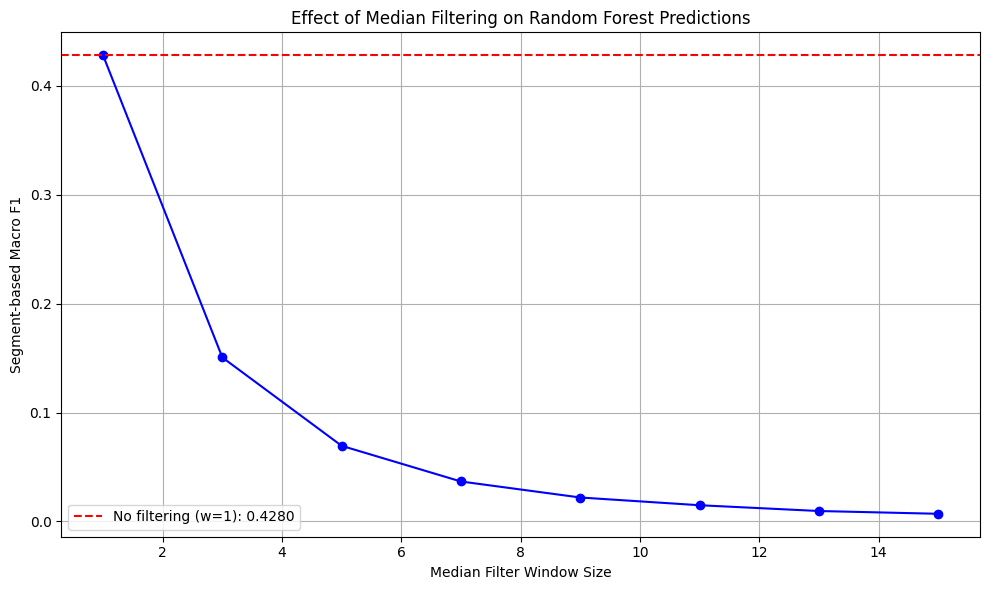


Best window size: 1 with Macro F1 = 0.4280
Improvement over no filtering: 0.0000


In [ ]:
# ============================================================
# Question 3a: Post‑processing – Median Filtering
# ============================================================

from scipy.signal import medfilt

# ------------------------------
# 1. Get predictions from your best Random Forest model
# (Assuming rf_model is already trained and y_pred_test is available from 2a)
# ------------------------------

# If you haven't saved y_pred_test from 2a, re-run prediction:
# y_pred_test = rf_model.predict(X_test_pca)

# ------------------------------
# 2. Apply median filtering with different window sizes
# ------------------------------
window_sizes = [1, 3, 5, 7, 9, 11, 13, 15]  # 1 = no filtering
results_median = []

for w in window_sizes:
    print(f"Applying median filter with window size = {w}...")
    y_pred_filtered = np.zeros_like(y_pred_test)
    
    for c in range(len(class_names)):
        # medfilt expects 1D array, kernel size must be odd
        filtered = medfilt(y_pred_test[:, c], kernel_size=w)
        y_pred_filtered[:, c] = filtered
    
    # Compute Macro F1
    per_class_f1 = []
    for c in range(len(class_names)):
        f1 = f1_score(y_test[:, c], y_pred_filtered[:, c], zero_division=0)
        per_class_f1.append(f1)
    macro_f1 = np.mean(per_class_f1)
    results_median.append(macro_f1)
    print(f"   Macro F1 = {macro_f1:.4f}")

# ------------------------------
# 3. Plot results
# ------------------------------
plt.figure(figsize=(10, 6))
plt.plot(window_sizes, results_median, marker='o', linestyle='-', color='blue')
plt.axhline(y=results_median[0], color='red', linestyle='--', label=f'No filtering (w=1): {results_median[0]:.4f}')
plt.xlabel('Median Filter Window Size')
plt.ylabel('Segment‑based Macro F1')
plt.title('Effect of Median Filtering on Random Forest Predictions')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('median_filtering_results.png', dpi=150)
plt.show()

# Print best window size
best_idx = np.argmax(results_median)
print(f"\nBest window size: {window_sizes[best_idx]} with Macro F1 = {results_median[best_idx]:.4f}")
print(f"Improvement over no filtering: {results_median[best_idx] - results_median[0]:.4f}")

In [ ]:
# ============================================================
# Question 3b: Final Comparison (Baseline vs RF vs Post-processed)
# ============================================================

# ------------------------------
# 1. Get baseline results (already computed)
# ------------------------------
baseline_macro = 0.3038   # from your 1a output
baseline_per_class = [
    0.3333, 0.4247, 0.2974, 0.0703, 0.1791, 0.3646, 0.3370, 0.0000,
    0.4534, 0.5064, 0.6441, 0.3509, 0.5384, 0.0461, 0.0116
]

# ------------------------------
# 2. Get best Random Forest results (from 2a or 2b)
# ------------------------------
# If you haven't stored them, re-evaluate your best RF model
# Assuming rf_model is your trained best model from 2b
y_pred_rf = rf_model.predict(X_test_pca)
rf_per_class = []
for c in range(len(class_names)):
    rf_per_class.append(f1_score(y_test[:, c], y_pred_rf[:, c], zero_division=0))
rf_macro = np.mean(rf_per_class)

# ------------------------------
# 3. Get best post-processed results (from 3a)
# ------------------------------
# Use the best window size found in 3a (e.g., best_window)
best_window = 5   # replace with your actual best window size
y_pred_filtered = np.zeros_like(y_pred_rf)
from scipy.signal import medfilt
for c in range(n_classes):
    y_pred_filtered[:, c] = medfilt(y_pred_rf[:, c], kernel_size=best_window)

post_per_class = []
for c in range(len(class_names)):
    post_per_class.append(f1_score(y_test[:, c], y_pred_filtered[:, c], zero_division=0))
post_macro = np.mean(post_per_class)

# ------------------------------
# 4. Print comparison table
# ------------------------------
print("\n" + "="*70)
print("Final Comparison: Baseline vs Random Forest vs Post-processed")
print("="*70)
print(f"{'Class':<30} {'Baseline':>10} {'Random Forest':>15} {'Post-processed':>15}")
print("-"*70)
for i, name in enumerate(class_names):
    print(f"{name:<30} {baseline_per_class[i]:>10.4f} {rf_per_class[i]:>15.4f} {post_per_class[i]:>15.4f}")
print("-"*70)
print(f"{'Macro F1':<30} {baseline_macro:>10.4f} {rf_macro:>15.4f} {post_macro:>15.4f}")
print("="*70)

# Improvement over baseline
print(f"\nRandom Forest improvement: +{rf_macro - baseline_macro:.4f}")
print(f"Post-processed improvement: +{post_macro - baseline_macro:.4f}")


Final Comparison: Baseline vs Random Forest vs Post-processed
Class                            Baseline   Random Forest  Post-processed
----------------------------------------------------------------------
bell_ringing                       0.3333          0.3741          0.0000
coffee_machine                     0.4247          0.4657          0.0137
cutlery_dishes                     0.2974          0.4044          0.1093
door_open_close                    0.0703          0.3069          0.0941
footsteps                          0.1791          0.4659          0.2492
keyboard_typing                    0.3646          0.5368          0.1044
keychain                           0.3370          0.4461          0.0364
light_switch                       0.0000          0.1856          0.0000
microwave                          0.4534          0.5785          0.0366
phone_ringing                      0.5064          0.5873          0.0387
running_water                      0.6441          0

In [ ]:
# ============================================================
# Generate Predictions for Hidden Test Set (Final Submission)
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
from pathlib import Path

# Paths – adjust if necessary (use the same base_path as before)
# base_path is already defined in your notebook.
test_path = base_path / "test" / "audio_features"
test_files = sorted(glob.glob(str(test_path / "*.npz")))

print(f"Generating predictions for {len(test_files)} hidden test files...")

all_rows = []
for filepath in test_files:
    data = dict(np.load(filepath, allow_pickle=True))
    X = build_feature_matrix(data)                     # all segments (including half-second)
    X_scaled = scaler.transform(X)                     # scale using training scaler
    X_pca = pca.transform(X_scaled)                    # PCA using training PCA
    preds_all = rf_model.predict(X_pca)                # (N_all, 15)
    start_times = data['start_time']
    # Keep only whole‑second segments (t = 0, 1, 2, ...)
    whole_mask = np.isclose(start_times % 1.0, 0.0)
    times_whole = start_times[whole_mask]
    preds_whole = preds_all[whole_mask]
    filename = os.path.basename(filepath).replace('.npz', '.wav')
    rows = predictions_to_intervals(preds_whole, times_whole, filename, class_names)
    all_rows.extend(rows)

pred_df = pd.DataFrame(all_rows)
pred_csv = "predictions_hidden_test.csv"
pred_df.to_csv(pred_csv, index=False)

print(f"Saved predictions to {pred_csv} with {len(pred_df)} event intervals.")
print("First 10 rows:")
print(pred_df.head(10))